In [1]:
%load_ext autoreload
%autoreload 2

In [27]:
%restart

UsageError: Line magic function `%restart` not found.


In [2]:
from hybrid_search_rrf_dataset.retrieval import SciFact

facts_db = SciFact()

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
facts_db.save()

[INFO] Opening /Users/andrei/.ir_datasets/beir/scifact/docs.pklz4/bin with direct file access


In [4]:
facts_db.queries()

,query_id,text
0,1,0-dimensional biomaterials show inductive prop...
1,3,"1,000 genomes project enables mapping of genet..."
2,5,1/2000 in UK have abnormal PrP positivity.
3,13,5% of perinatal mortality is due to low birth ...
4,36,A deficiency of vitamin B12 increases blood le...
...,...,...
295,1379,Women with a higher birth weight are more like...
296,1382,aPKCz causes tumour enhancement by affecting g...
297,1385,cSMAC formation enhances weak ligand signalling.
298,1389,mTORC2 regulates intracellular cysteine levels...


In [5]:
facts_db.corpus()

[INFO] Opening /Users/andrei/.ir_datasets/beir/scifact/docs.pklz4/bin with direct file access


,doc_id,title,text
0,4983,Microstructural development of human newborn c...,Alterations of the architecture of cerebral wh...
1,5836,Induction of myelodysplasia by myeloid-derived...,Myelodysplastic syndromes (MDS) are age-depend...
2,7912,"BC1 RNA, the transcript from a master gene for...",ID elements are short interspersed elements (S...
3,18670,The DNA Methylome of Human Peripheral Blood Mo...,DNA methylation plays an important role in bio...
4,19238,The human myelin basic protein gene is include...,Two human Golli (for gene expressed in the oli...
...,...,...,...
5178,195689316,Body-mass index and cause-specific mortality i...,BACKGROUND The main associations of body-mass ...
5179,195689757,Targeting metabolic remodeling in glioblastoma...,A key aberrant biological difference between t...
5180,196664003,Signaling architectures that transmit unidirec...,A signaling pathway transmits information from...
5181,198133135,"Association between pre-diabetes, type 2 diabe...",AIMS Trabecular bone score (TBS) is a surrogat...


In [6]:
facts_db.qrels()

,query_id,doc_id,relevance
0,1,31715818,1
1,3,14717500,1
2,5,13734012,1
3,13,1606628,1
4,36,5152028,1
...,...,...,...
334,1379,17450673,1
335,1382,17755060,1
336,1385,306006,1
337,1389,23895668,1


In [7]:
from hybrid_search_rrf_dataset.retrieval import NFCorpus

nf_df = NFCorpus()

nf_df.qrels()

,query_id,doc_id,relevance
0,PLAIN-2,MED-2427,2
1,PLAIN-2,MED-10,2
2,PLAIN-2,MED-2429,2
3,PLAIN-2,MED-2430,2
4,PLAIN-2,MED-2431,2
...,...,...,...
12329,PLAIN-3472,MED-3623,1
12330,PLAIN-3472,MED-3624,1
12331,PLAIN-3472,MED-3625,1
12332,PLAIN-3472,MED-3626,1


In [8]:
nf_df.save()

[INFO] Opening /Users/andrei/.ir_datasets/beir/nfcorpus/docs.pklz4/bin with direct file access


In [9]:
from hybrid_search_rrf_dataset.indexer import (
    CorpusDocument,
    CorpusIndexer,
    EmbeddingConfig,
)

docs = [CorpusDocument(**row) for row in nf_df.corpus().to_dict('records')]

[INFO] Opening /Users/andrei/.ir_datasets/beir/nfcorpus/docs.pklz4/bin with direct file access


In [10]:
# constants
COLLECTION_NAME = 'rrf-dataset'
DENSE_MODEL = "BAAI/bge-small-en-v1.5"
SIZE = 384

In [11]:
import os

from qdrant_client import QdrantClient

qdrant_url = os.getenv('QDRANT_URL')
qdrant_api_key = os.getenv('QDRANT_API_KEY')

client = QdrantClient(url=qdrant_url, api_key=qdrant_api_key)

/var/folders/pq/gsx7ryn905s1bypf32zs4k980000gn/T/ipykernel_29881/4135368465.py:8: UserWarning: Api key is used with an insecure connection.
  client = QdrantClient(url=qdrant_url, api_key=qdrant_api_key)


In [12]:
from qdrant_client.models import Distance

dense_config = config = EmbeddingConfig(
    name='dense_base',
    model_id=DENSE_MODEL,
    kind='dense',
    size=SIZE,
    distance=Distance.COSINE,
    providers=["CoreMLExecutionProvider", "CPUExecutionProvider"],
    parallel=None,
)

sparse_config = EmbeddingConfig(
    name='sparse_base',
    providers=["CoreMLExecutionProvider", "CPUExecutionProvider"],
    model_id='qdrant/bm25',
    kind='sparse',
    parallel=None
)
embeddings: list[EmbeddingConfig] = [
    dense_config,
    sparse_config
]

indexer = CorpusIndexer(client, "nf", embeddings=embeddings)

In [13]:
indexer.ensure_collection()
indexer.upload(docs)

embed:dense_base:   5%|▌         | 192/3633 [00:08<02:23, 23.96it/s]


KeyboardInterrupt: 

In [13]:
from hybrid_search_rrf_dataset.retrieval import TrecDL2022

trec_dl = TrecDL2022(30000)
trec_dl.materialize()
trec_dl.save()

materialize:trec-dl-2022:  37%|███▋      | 50726807/138364198 [02:25<04:11, 348313.65it/s]


In [14]:
len(trec_dl.qrels()), len(trec_dl.corpus()), len(trec_dl.queries())

(117206, 30000, 76)

In [15]:
trec_dl.qrels()

,query_id,doc_id,relevance
0,2000511,msmarco_passage_00_491550793,0
1,2000511,msmarco_passage_00_491572639,0
2,2000511,msmarco_passage_00_491574814,0
3,2000511,msmarco_passage_00_491575627,0
4,2000511,msmarco_passage_00_491576817,0
...,...,...,...
117201,2056323,msmarco_passage_23_151685534,0
117202,2056323,msmarco_passage_25_116565148,0
117203,2056323,msmarco_passage_25_54427309,0
117204,2056323,msmarco_passage_25_54434635,0


In [16]:
trecdl_indexer = CorpusIndexer(client, "trec_dl", embeddings=embeddings)

In [17]:
trecdl_indexer.ensure_collection()

In [18]:
trec_dl.corpus()

,doc_id,text,spans,msmarco_document_id
0,msmarco_passage_00_1699199,inspirational nurse quote. A nurse is one who ...,"((14771, 14796), (14797, 14884), (14885, 14980...",msmarco_doc_00_4032125
1,msmarco_passage_00_2064501,Earlier in the year we learned about the Pilgr...,"((143, 227), (228, 289), (290, 346), (347, 415...",msmarco_doc_00_4699563
2,msmarco_passage_00_5517719,The Executive Branch. The executive branch is ...,"((3630, 3650), (3651, 3748), (3749, 3845), (38...",msmarco_doc_00_12059204
3,msmarco_passage_00_6794850,Identity of Interest Statement for HUD 203 (K)...,"((0, 58),)",msmarco_doc_00_16165216
4,msmarco_passage_00_6796317,Duties and Responsibilities of a HUD 203k cons...,"((47, 100),)",msmarco_doc_00_16167046
...,...,...,...,...
29995,msmarco_passage_25_314969675,"Code History. FY 2021 - No Change, effective f...","((2420, 2432), (2433, 2496), (2497, 2560), (25...",msmarco_doc_22_637817884
29996,msmarco_passage_25_314974796,"Code History. FY 2021 - No Change, effective f...","((4049, 4061), (4062, 4125), (4126, 4189), (41...",msmarco_doc_22_637821273
29997,msmarco_passage_25_314979273,"Code History. FY 2021 - No Change, effective f...","((3369, 3381), (3382, 3445), (3446, 3509), (35...",msmarco_doc_22_637826425
29998,msmarco_passage_25_314982359,"Code History. FY 2021 - No Change, effective f...","((2825, 2837), (2838, 2901), (2902, 2965), (29...",msmarco_doc_22_637830835


In [19]:
corpus_trecql = [
    CorpusDocument(doc_id=item['doc_id'], title=item['msmarco_document_id'], text=item['text']) 
    for item in trec_dl.corpus().to_dict('records')
]

In [28]:
len(corpus_trecql)

30000

In [33]:
trecdl_indexer.upload(corpus_trecql)

embed:sparse_base: 100%|██████████| 30000/30000 [00:00<00:00, 30353.28it/s]


In [20]:
from hybrid_search_rrf_dataset.golden import GoldenSetBuilder

golden_builder = GoldenSetBuilder(client, "trec_dl", dense_config, sparse_config)


In [21]:
golden_rows = golden_builder.build(trec_dl)

goldensetbuilder:trec-dl-2022: 100%|██████████| 76/76 [00:05<00:00, 14.09it/s]


In [41]:
[(row.alpha, row.metric, row.metric_name, row.query) for row in golden_rows]

[(0.0,
  0.33242345430952586,
  'NDCG@10',
  'average bahamas temperature at the end of october'),
 (0.0, 0.591457821214841, 'NDCG@10', 'business architect role definition'),
 (0.1,
  0.5682611233817609,
  'NDCG@10',
  'example of what a family advocate does'),
 (0.1,
  0.10001307161417164,
  'NDCG@10',
  'how do I replace the burners on a ducane grill'),
 (0.0,
  0.4074831792910295,
  'NDCG@10',
  'how do i insert notes under a slide in powerpoint'),
 (0.0, 0.2426178552850034, 'NDCG@10', 'how do you root a yucca plant'),
 (0.0, 0.5370919697444143, 'NDCG@10', 'how fast does a rabbit grow'),
 (0.1,
  0.16771752171325524,
  'NDCG@10',
  "how much average cost to plan a 8' tree?"),
 (0.6000000000000001, 0.607981426265653, 'NDCG@10', 'how to age steak'),
 (0.1,
  0.48262672908754745,
  'NDCG@10',
  'how to cook frozen ham steak on nuwave oven'),
 (0.1, 0.6887811365853285, 'NDCG@10', 'how to dilute ceftriaxone vial'),
 (0.5, 0.392816566021782, 'NDCG@10', 'how to put together a scuba regulat

In [22]:
import numpy as np 

np.mean([row.metric for row in golden_rows])

np.float64(0.5057703471965388)

- Internally consistent: for each query, we found the best α given these specific dense + sparse models. If you re-ran with the same encoders you'd get the same α values (deterministic).
- Globally best: the theoretical ceiling — the highest NDCG achievable by any retrieval configuration. You can't measure this with a single encoder pair.

In [23]:
import requests

llm_fusion_key = os.getenv('QDRANT_LLM_FUSION_KEY') or '0b1bb5fb4f8c98cb540b831e123f5ab0'
llm_fusion_url = os.getenv('QDRANT_LLM_FUSION_URL')

if not llm_fusion_key or not llm_fusion_url:
    raise RuntimeError("Cannot access the keys for the external api")


headers = {
    "Authorization": f"Bearer {llm_fusion_key}"
}

response = requests.post(llm_fusion_url,  headers=headers, json={ 'text': 'Iphone 3' })

print(response.json())  

{'score': 5, 'expected_score': 5.0, 'from_logprobs': False, 'model': 'mistralai/ministral-3b-2512', 'request_id': '01KWEHQEYM4XXN6EXY2WMNYAXP', 'service_duration_ms': 500, 'upstream_duration_ms': 500}


In [24]:
from hybrid_search_rrf_dataset.golden import LLMFusionBuilder

llm_fusion_builder = LLMFusionBuilder(client, "trec_dl", dense_config, sparse_config)

In [28]:
llm_fusion_results = llm_fusion_builder.build_or_load(trec_dl)

llmfusionbuilder:trec-dl-2022: 100%|██████████| 76/76 [00:58<00:00,  1.29it/s]


In [30]:
[(row.alpha, row.metric, row.metric_name, row.query) for row in llm_fusion_results]

[(0.1111111111111111,
  0.17853823829819596,
  'NDCG@10',
  'average bahamas temperature at the end of october'),
 (0.3333333333333333,
  0.1755949289024632,
  'NDCG@10',
  'business architect role definition'),
 (0.3333333333333333,
  0.4955826835557904,
  'NDCG@10',
  'example of what a family advocate does'),
 (0.3333333333333333,
  0.10001307161417164,
  'NDCG@10',
  'how do I replace the burners on a ducane grill'),
 (0.2222222222222222,
  0.28178107674964303,
  'NDCG@10',
  'how do i insert notes under a slide in powerpoint'),
 (0.1111111111111111,
  0.13886244387355454,
  'NDCG@10',
  'how do you root a yucca plant'),
 (0.1111111111111111,
  0.44598161823433174,
  'NDCG@10',
  'how fast does a rabbit grow'),
 (0.3333333333333333,
  0.15368188299909635,
  'NDCG@10',
  "how much average cost to plan a 8' tree?"),
 (0.0, 0.5571058317608684, 'NDCG@10', 'how to age steak'),
 (0.3333333333333333,
  0.48262672908754745,
  'NDCG@10',
  'how to cook frozen ham steak on nuwave oven'),
 (0

In [31]:
from hybrid_search_rrf_dataset.evaluation import compare, plot_comparison

summary = compare(golden=golden_rows, candidate=llm_fusion_results)
print(summary)

n_queries=76 alpha_mae=0.25000000000000006 alpha_pearson=0.04509909009870499 alpha_within_tolerance_pct=18.421052631578945 mean_metric_golden=0.5057703471965388 mean_metric_candidate=0.41587259563878076 mean_regret=0.0898977515577581 max_regret=0.41586289231237783


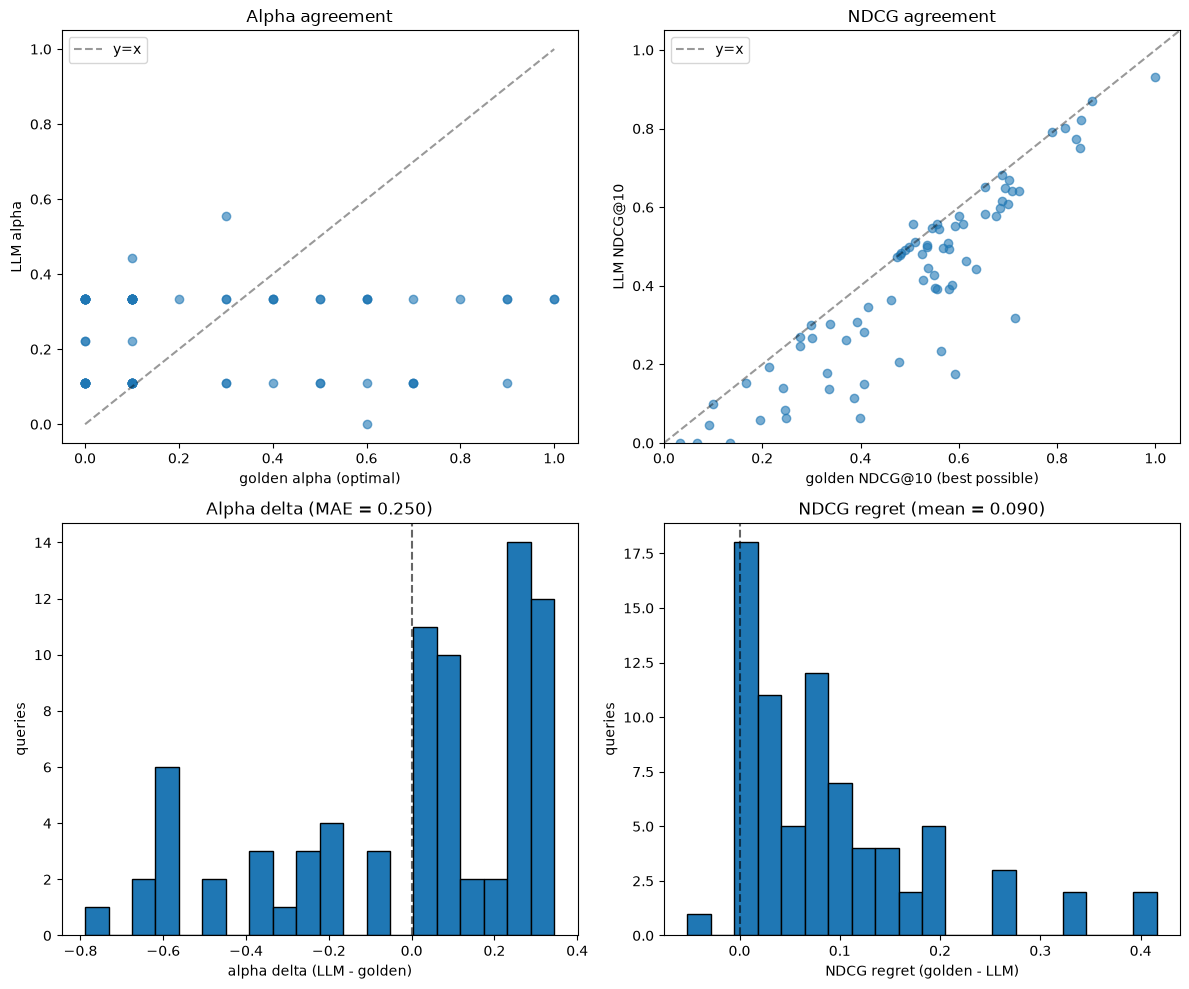

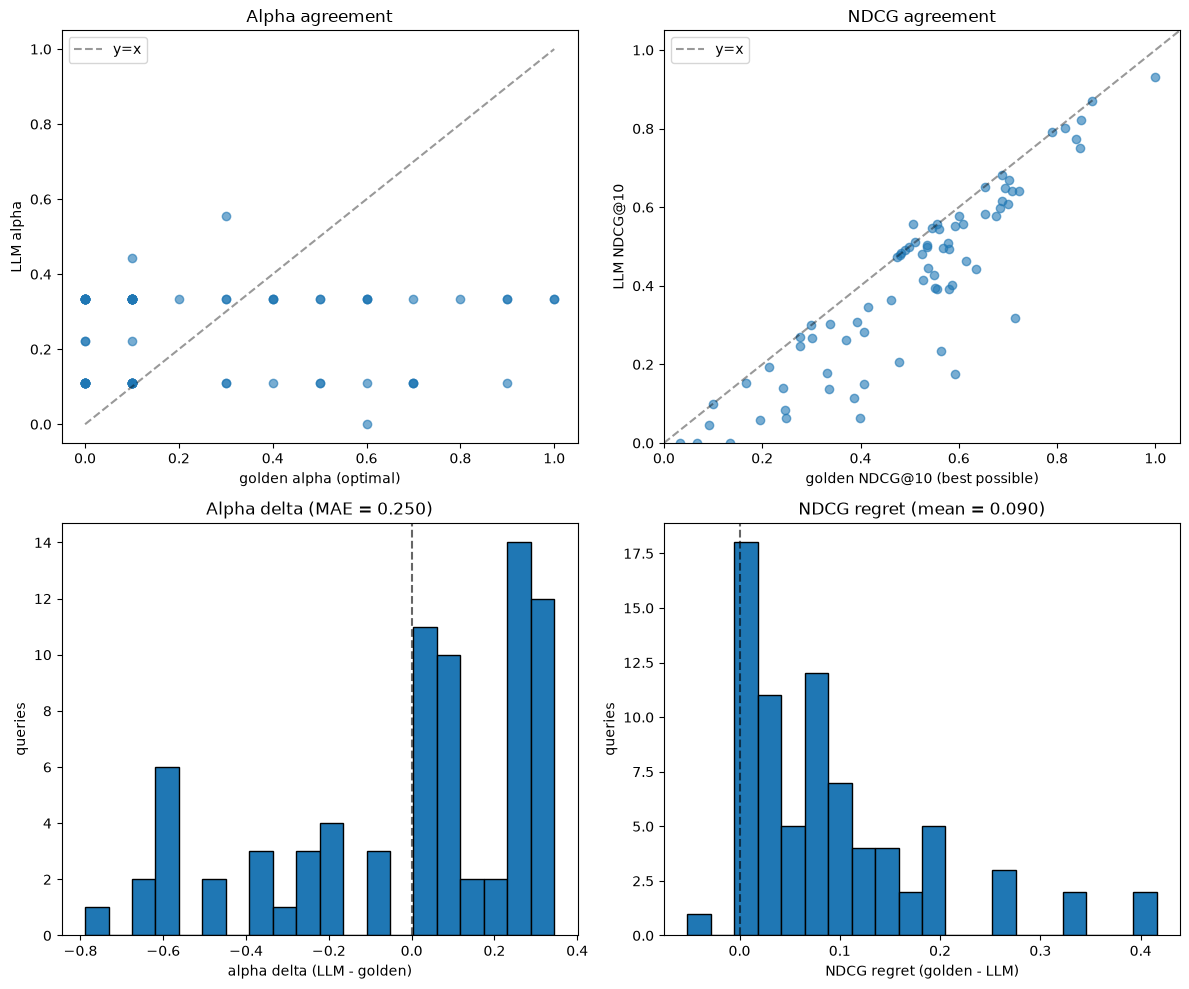

In [32]:
plot_comparison(golden=golden_rows, candidate=llm_fusion_results, candidate_label="LLM")